# Indel-call accuracy on the CAMI metagenome set: FGS vs. DeepCDS S+I

Adapted from `with_errors/indel_reads_mae.ipynb`. Compares the two indel-aware FGS
error models (Illumina 0.5%% / 1.0%%) against DeepCDS S+I on how well each recovers the
*positions* of indels within a read's coding region - not CDS boundaries (see the other
two notebooks in this folder for that). FGS Complete is left out, same as the original
notebook, since it doesn't model indels at all. Ground truth here comes from the real
CIGAR-derived indel positions written by `process_and_map_CAMI_testset.py`.

In [1]:
import glob
import os
import pickle
import re
import sys

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, FONT_SIZES

plt.rcParams['figure.dpi'] = 300
plt.rcParams.update(FONT_SIZES)

In [2]:
# SCARB cluster data root - matches the project_root convention used by
# postprocess_metagenome_testset.py / postprocess_metagenome/*.py, since that's
# where all of this notebook's inputs actually live on this machine.
project_root = "/tmp/nrt204/FragmentPredictor"

data_dir = "CAMI_metagenome"  # matches predict_metagenome/ and postprocess_metagenome/ convention

# When True, evaluate against the version of the test set (and predictions) with reads
# overlapping a hypothetical-protein / ab-initio-prediction-tagged CDS removed entirely -
# see postprocess_metagenome_testset.py / postprocess_metagenome/*.py's
# EXCLUDE_UNCERTAIN_REGION_READS toggle of the same name. Requires having already run
# those scripts with that toggle on; raises FileNotFoundError below otherwise.
EXCLUDE_UNCERTAIN_REGION_READS = False

# testset_processed/ and processed_predictions/ are both written under this directory
# name by the postprocessing scripts (see their EXCLUDE_UNCERTAIN_REGION_READS toggle) -
# raw reads_processed/ is never filtered, so it stays keyed on plain data_dir.
eval_data_dir = data_dir + ("_no_ab_initio" if EXCLUDE_UNCERTAIN_REGION_READS else "")

# FGS Complete has no error model, so it never predicts indels - only the two
# error-aware FGS variants and DeepCDS S+I are meaningful here.
MODEL_KEYS = ["fgs_illumina_5", "fgs_illumina_10", "deep_cds_errors"]

# Load data if already processed; set to False to re-run data processing and overwrite cached results
LOAD_PROCESSED_DATA = True

In [3]:
samples = sorted(
    os.path.basename(p) for p in
    glob.glob(f"{project_root}/data/processed_data/testset_processed/{eval_data_dir}/*")
    if os.path.isdir(p)
)
if not samples:
    raise FileNotFoundError(
        f"No processed CAMI testsets found under data/processed_data/testset_processed/{eval_data_dir}/"
        + (" - run postprocess_metagenome_testset.py with EXCLUDE_UNCERTAIN_REGION_READS=True first."
           if EXCLUDE_UNCERTAIN_REGION_READS else "")
    )
print(f"CAMI samples: {samples}")
print(f"Comparing models: {MODEL_KEYS}")

_script_name = "indel_reads_mae_metagenome"
_cache_dir = f"{project_root}/data/processed_data/report_results/{eval_data_dir}/{_script_name}"

CAMI samples: ['sample_0']
Comparing models: ['fgs_illumina_5', 'fgs_illumina_10', 'deep_cds_errors']


## Helpers (unchanged from the genome-benchmark notebook)

In [4]:
def get_indel_positions(reads_dict):
    """Keep only the reads that actually have a nonzero seq_error_positions list."""
    seq_errors_read_dict = {}

    for read in reads_dict.keys():
        seq_error_info = reads_dict[read]['seq_error_positions']

        if len(seq_error_info) == 0:
            continue

        seq_errors_read_dict[read] = seq_error_info

    return seq_errors_read_dict


def calculate_mae(testset_dict, preds_dict):
    """TP/FN/FP indel-position counts, mean absolute distance of matched positions
    (MAE), precision and sensitivity - via greedy nearest-position one-to-one matching
    between ground-truth and predicted indel positions on each shared read.

    Args:
        testset_dict: read_name -> list of ground-truth indel position strings (e.g. "38I").
        preds_dict: read_name -> list of predicted indel position strings.

    Returns:
        Tuple of (indel_TP, indel_FN, indel_FP, MAE, precision, sensitivity).
    """
    err_positions = []
    indel_TP = 0
    indel_FP = 0
    indel_FN = 0

    in_testset = testset_dict.keys()
    in_preds   = preds_dict.keys()

    intersections   = list(set(in_testset).intersection(set(in_preds)))
    only_in_testset = list(set(in_testset).difference(set(in_preds)))
    only_in_preds   = list(set(in_preds).difference(set(in_testset)))

    # Reads with indels in testset but no predicted indel: all testset indels are FN
    for read in only_in_testset:
        indel_FN += len(testset_dict[read])

    # Reads with predicted indels but no testset indel: all predicted indels are FP
    for read in only_in_preds:
        indel_FP += len(preds_dict[read])

    # Reads with indels in both: greedy one-to-one matching by minimum distance
    for read in intersections:
        testset_err = [int(re.match(r"\d+", v).group()) for v in testset_dict[read]]
        preds_err   = [int(re.match(r"\d+", v).group()) for v in preds_dict[read]]

        pairs = sorted(
            (abs(t - p), ti, pi)
            for ti, t in enumerate(testset_err)
            for pi, p in enumerate(preds_err)
        )
        matched_t = set()
        matched_p = set()
        for dist, ti, pi in pairs:
            if ti not in matched_t and pi not in matched_p:
                err_positions.append(dist)
                matched_t.add(ti)
                matched_p.add(pi)

        indel_TP += len(matched_t)
        indel_FN += len(testset_err) - len(matched_t)
        indel_FP += len(preds_err)   - len(matched_p)

    precision   = indel_TP / (indel_TP + indel_FP) if (indel_TP + indel_FP) > 0 else 0
    sensitivity = indel_TP / (indel_TP + indel_FN) if (indel_TP + indel_FN) > 0 else 0

    return indel_TP, indel_FN, indel_FP, np.mean(err_positions) if err_positions else np.nan, precision, sensitivity

In [5]:
def load_processed_datasets(sample, project_root=project_root):
    """Load ground truth + FGS/DeepCDS-S+I predictions for a CAMI sample, all reduced
    to read_name -> indel-position-list via get_indel_positions().

    Returns:
        Tuple of (read_names_list, testset_indels, preds_indels) where preds_indels is
        {model_key: {read_name: [indel_position_strings]}} for whichever of MODEL_KEYS
        have processed predictions available.
    """
    ckpt = "full_model_all_genomes_seed_42_trained_final_8M_no_dropout"
    pred_paths = {
        "fgs_illumina_5": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{eval_data_dir}_illumina_5/{sample}.pkl",
        "fgs_illumina_10": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{eval_data_dir}_illumina_10/{sample}.pkl",
        "deep_cds_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_errors/{eval_data_dir}/{ckpt}/{sample}/model_preds_dict.pkl",
    }

    with open(f"{project_root}/data/processed_data/testset_processed/{eval_data_dir}/{sample}/testset_dict.pkl", "rb") as f:
        testset_dict = pickle.load(f)
    with open(f"{project_root}/data/processed_data/testset_processed/{eval_data_dir}/{sample}/read_names_list.pkl", "rb") as f:
        read_names_list = pickle.load(f)

    preds_indels = {}
    for model in MODEL_KEYS:
        try:
            with open(pred_paths[model], "rb") as f:
                preds_indels[model] = get_indel_positions(pickle.load(f))
        except FileNotFoundError:
            print(f"  No predictions found for {model} on {sample} - skipping it for this sample.")

    return read_names_list, get_indel_positions(testset_dict), preds_indels


def load_read_metadata(sample, project_root=project_root):
    """read_name -> {'genome_bin_id', 'domain'}, from the sample's CDS-labeled TSV.

    Used to break results down by community member below - not needed for the
    overall precision/sensitivity/MAE numbers. Reads raw reads_processed/ (data_dir,
    not eval_data_dir) - that TSV is never filtered by the ab-initio-exclusion toggle,
    only testset_processed/ and processed_predictions/ are.
    """
    tsv_path = f"{project_root}/data/processed_data/reads_processed/test/{data_dir}/{sample}_cds_labels.tsv.gz"
    df = pd.read_csv(tsv_path, sep="\t", compression="gzip", usecols=["read_name", "genome_bin_id", "domain"])
    return df.set_index("read_name")[["genome_bin_id", "domain"]].to_dict("index")


def partition_by_genome_bin(indel_dict, read_meta):
    """Split a {read_name: [...]} dict into {genome_bin_id: {read_name: [...]}}."""
    partitioned = {}
    for read_name, positions in indel_dict.items():
        bin_id = read_meta.get(read_name, {}).get("genome_bin_id", "Unknown")
        partitioned.setdefault(bin_id, {})[read_name] = positions
    return partitioned

# Compute indel-call metrics, overall and per community member

In [6]:
_expected_cache_files = ["overall_results.pkl", "per_genome_bin_results.pkl"]

_should_compute = True

if LOAD_PROCESSED_DATA:
    _cache_ok = os.path.isdir(_cache_dir) and all(
        os.path.isfile(os.path.join(_cache_dir, f)) for f in _expected_cache_files
    )
    if _cache_ok:
        print(f"Loading pre-computed results from:\n  {_cache_dir}")
        with open(os.path.join(_cache_dir, "overall_results.pkl"), "rb") as f:
            overall_results = pickle.load(f)
        with open(os.path.join(_cache_dir, "per_genome_bin_results.pkl"), "rb") as f:
            per_genome_bin_results = pickle.load(f)
        _should_compute = False
    else:
        print("Warning: No cached data found.")
        print(f"  Expected cache path: {_cache_dir}")
        print("  Falling back to full data processing...")

if _should_compute:
    # Single pooled TP/FN/FP/MAE/precision/sensitivity/F1 per model, across every read
    # in every sample - the metagenome analog of the genome benchmark's single number
    # per (model, read length).
    overall_results = {model: None for model in MODEL_KEYS}

    # Per-community-member (genome_bin_id) precision/sensitivity/MAE/F1 lists, for box
    # plots - the metagenome analog of the genome benchmark's per-test-genome lists.
    per_genome_bin_results = {
        model: {"precisions": [], "sensitivities": [], "MAEs": [], "f1s": []}
        for model in MODEL_KEYS
    }

    for sample in samples:
        print(f"\nProcessing {sample}...")
        read_names_list, testset_indels, preds_indels = load_processed_datasets(sample)
        read_meta = load_read_metadata(sample)

        testset_by_bin = partition_by_genome_bin(testset_indels, read_meta)

        for model in MODEL_KEYS:
            if model not in preds_indels:
                continue
            preds_dict = preds_indels[model]

            # Overall (pooled across the whole sample)
            TP, FN, FP, MAE, precision, sensitivity = calculate_mae(testset_indels, preds_dict)
            f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0
            overall_results[model] = {
                "TP": TP, "FN": FN, "FP": FP, "MAE": MAE,
                "precision": precision, "sensitivity": sensitivity, "f1": f1,
            }

            # Per genome bin
            preds_by_bin = partition_by_genome_bin(preds_dict, read_meta)
            all_bins = set(testset_by_bin) | set(preds_by_bin)
            for bin_id in tqdm(all_bins, desc=f"{sample} / {model}"):
                t_sub = testset_by_bin.get(bin_id, {})
                p_sub = preds_by_bin.get(bin_id, {})
                if not t_sub and not p_sub:
                    continue

                _, _, _, bin_mae, bin_precision, bin_sensitivity = calculate_mae(t_sub, p_sub)
                bin_f1 = (2 * bin_precision * bin_sensitivity / (bin_precision + bin_sensitivity)
                          if (bin_precision + bin_sensitivity) > 0 else 0.0)

                r = per_genome_bin_results[model]
                r["precisions"].append(bin_precision)
                r["sensitivities"].append(bin_sensitivity)
                r["MAEs"].append(bin_mae)
                r["f1s"].append(bin_f1)

  Expected cache path: /tmp/nrt204/FragmentPredictor/data/processed_data/report_results/CAMI_metagenome/indel_reads_mae_metagenome
  Falling back to full data processing...

Processing sample_0...


sample_0 / deep_cds_errors: 100%|██████████| 196/196 [00:00<00:00, 6821.03it/s]


In [7]:
if _should_compute:
    os.makedirs(_cache_dir, exist_ok=True)
    with open(os.path.join(_cache_dir, "overall_results.pkl"), "wb") as f:
        pickle.dump(overall_results, f)
    with open(os.path.join(_cache_dir, "per_genome_bin_results.pkl"), "wb") as f:
        pickle.dump(per_genome_bin_results, f)
    print(f"Results saved to {_cache_dir}")

Results saved to /tmp/nrt204/FragmentPredictor/data/processed_data/report_results/CAMI_metagenome/indel_reads_mae_metagenome


# Headline numbers (pooled across the whole sample)

In [8]:
model_display_names = MODEL_DISPLAY_NAMES
model_colors = MODEL_COLORS

for model in MODEL_KEYS:
    r = overall_results.get(model)
    if r is None:
        print(f"{model_display_names.get(model, model)}: no predictions available")
        continue
    print(f"{model_display_names.get(model, model)}: "
          f"TP={r['TP']:,} FN={r['FN']:,} FP={r['FP']:,}  "
          f"MAE={r['MAE']:.3f}  precision={r['precision']:.3f}  "
          f"sensitivity={r['sensitivity']:.3f}  F1={r['f1']:.3f}")

FGS (0.5% error rate): TP=2,336 FN=3,616 FP=1,053,794  MAE=9.735  precision=0.002  sensitivity=0.392  F1=0.004
FGS (1.0% error rate): TP=2,663 FN=3,289 FP=1,479,139  MAE=10.122  precision=0.002  sensitivity=0.447  F1=0.004
DeepCDS S+I: TP=1,874 FN=4,078 FP=44,244  MAE=5.812  precision=0.041  sensitivity=0.315  F1=0.072


# Plot: distribution across CAMI community members

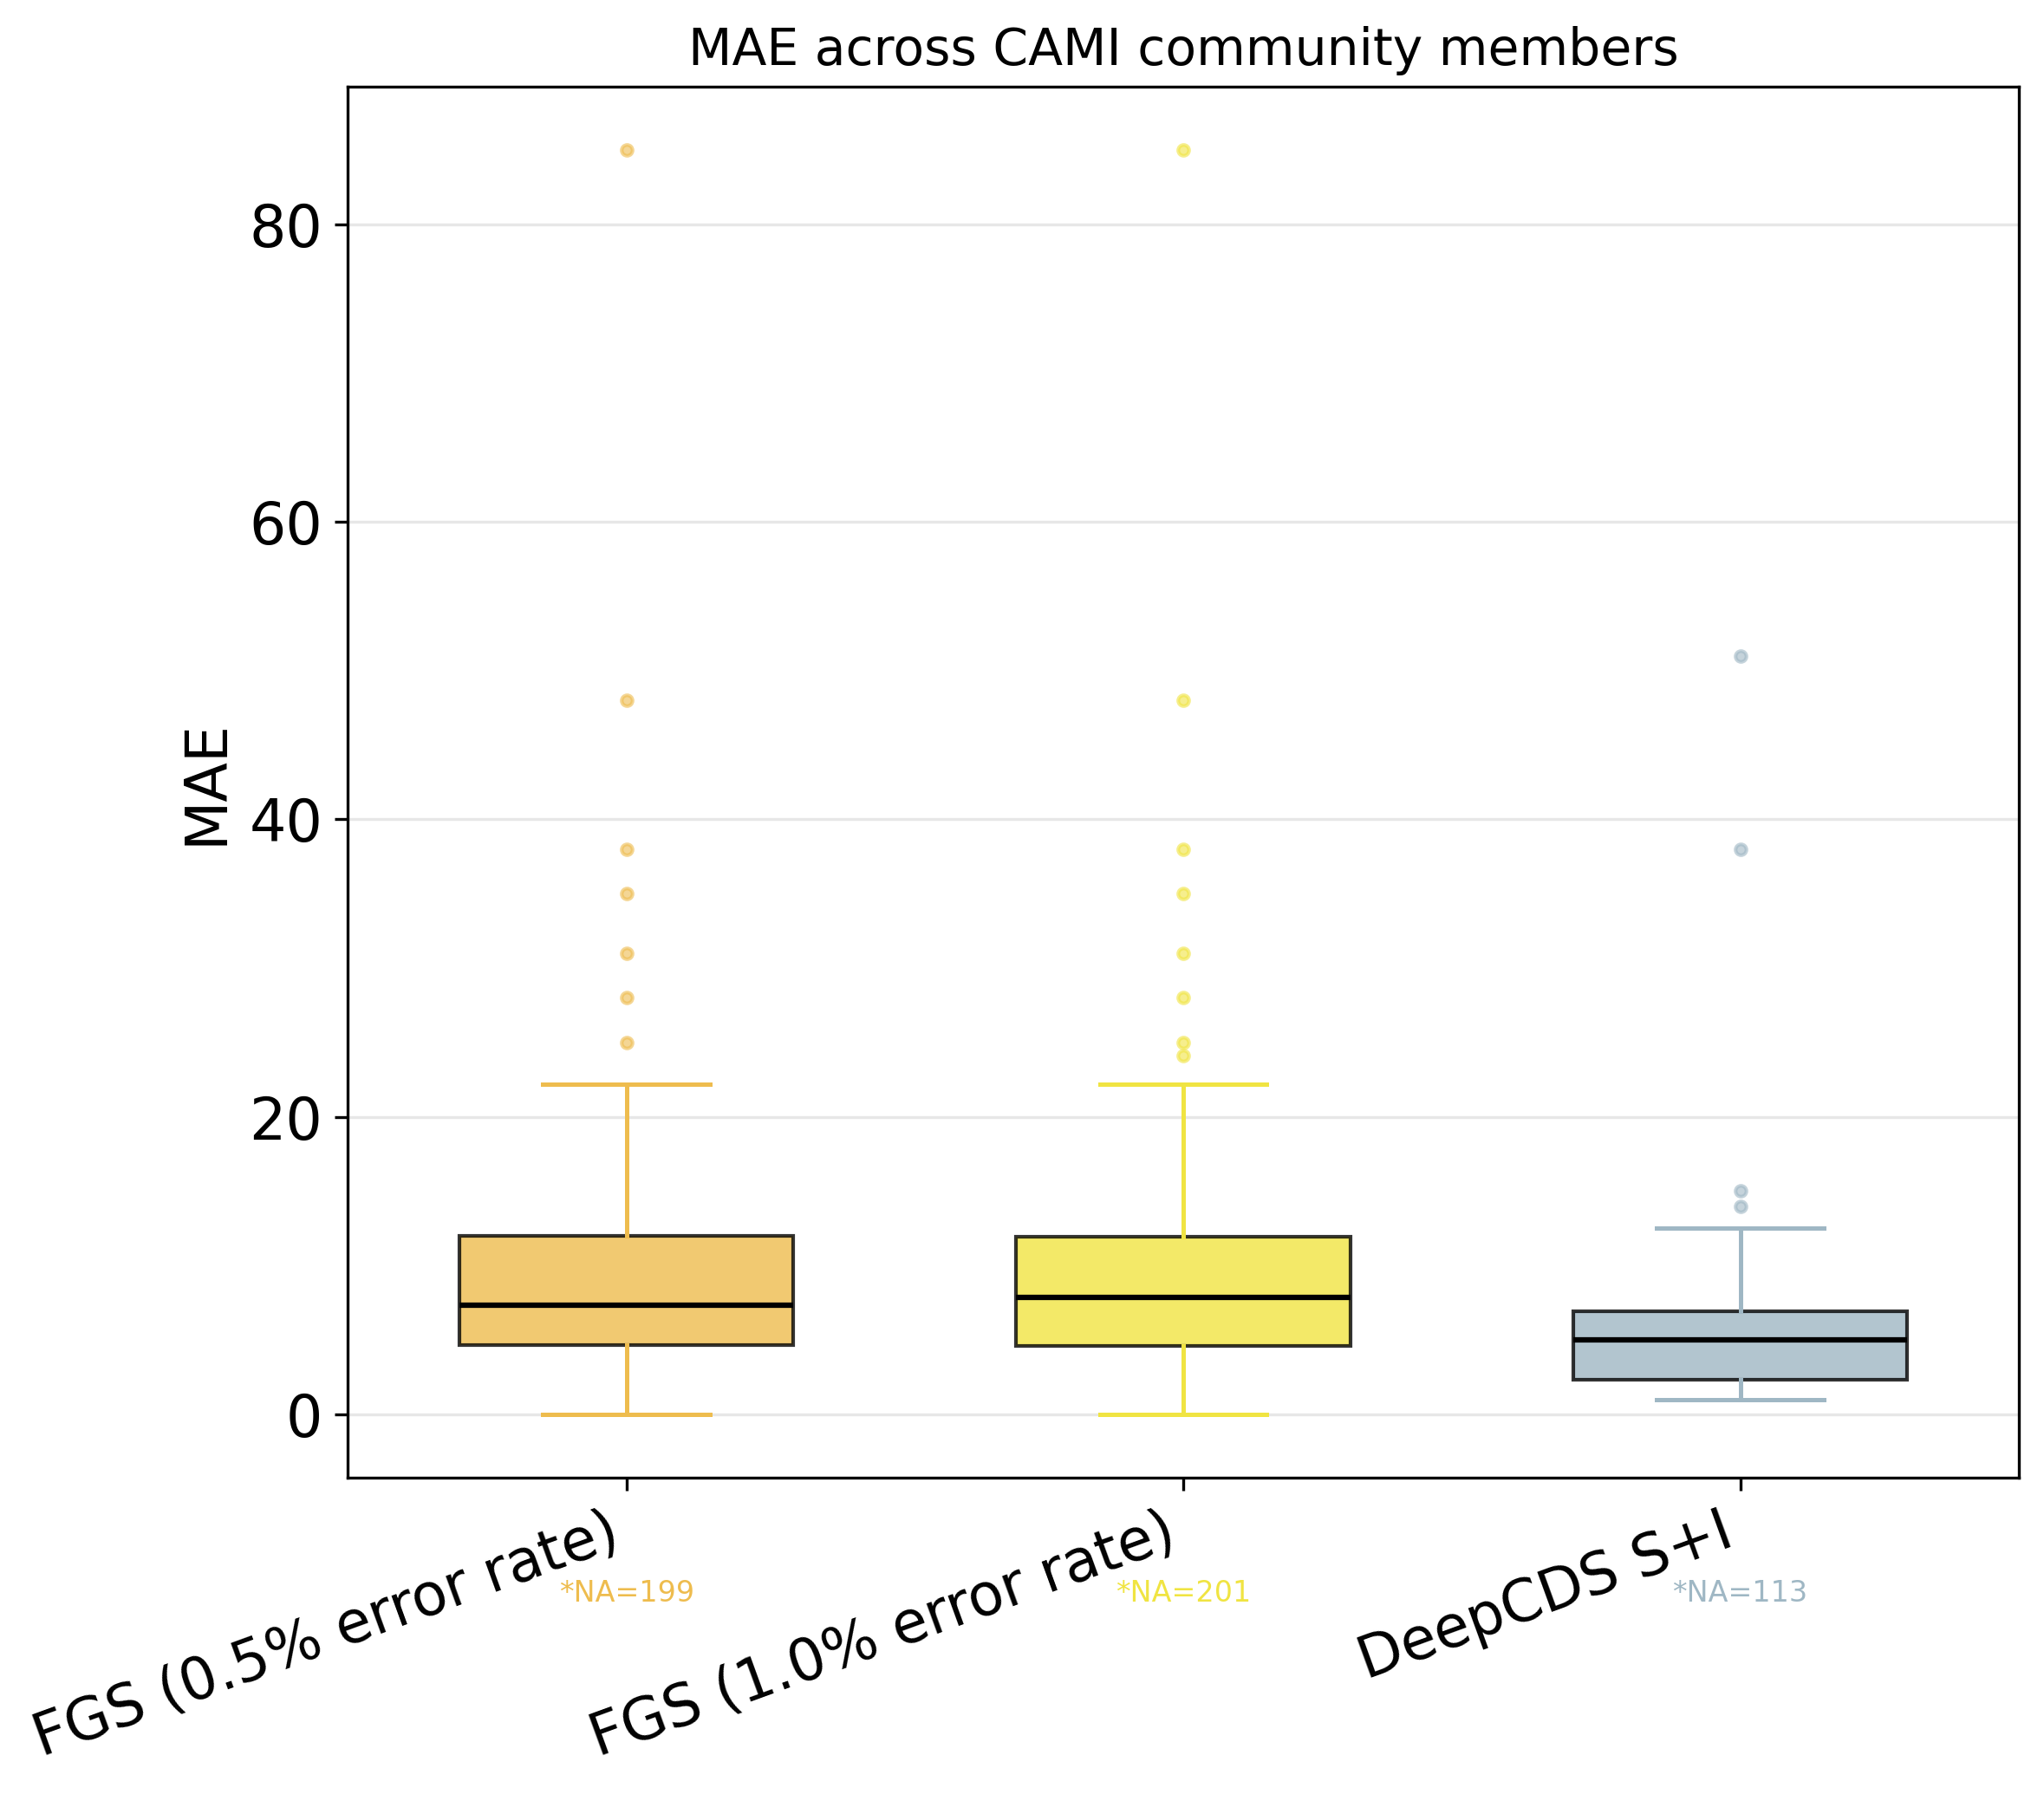

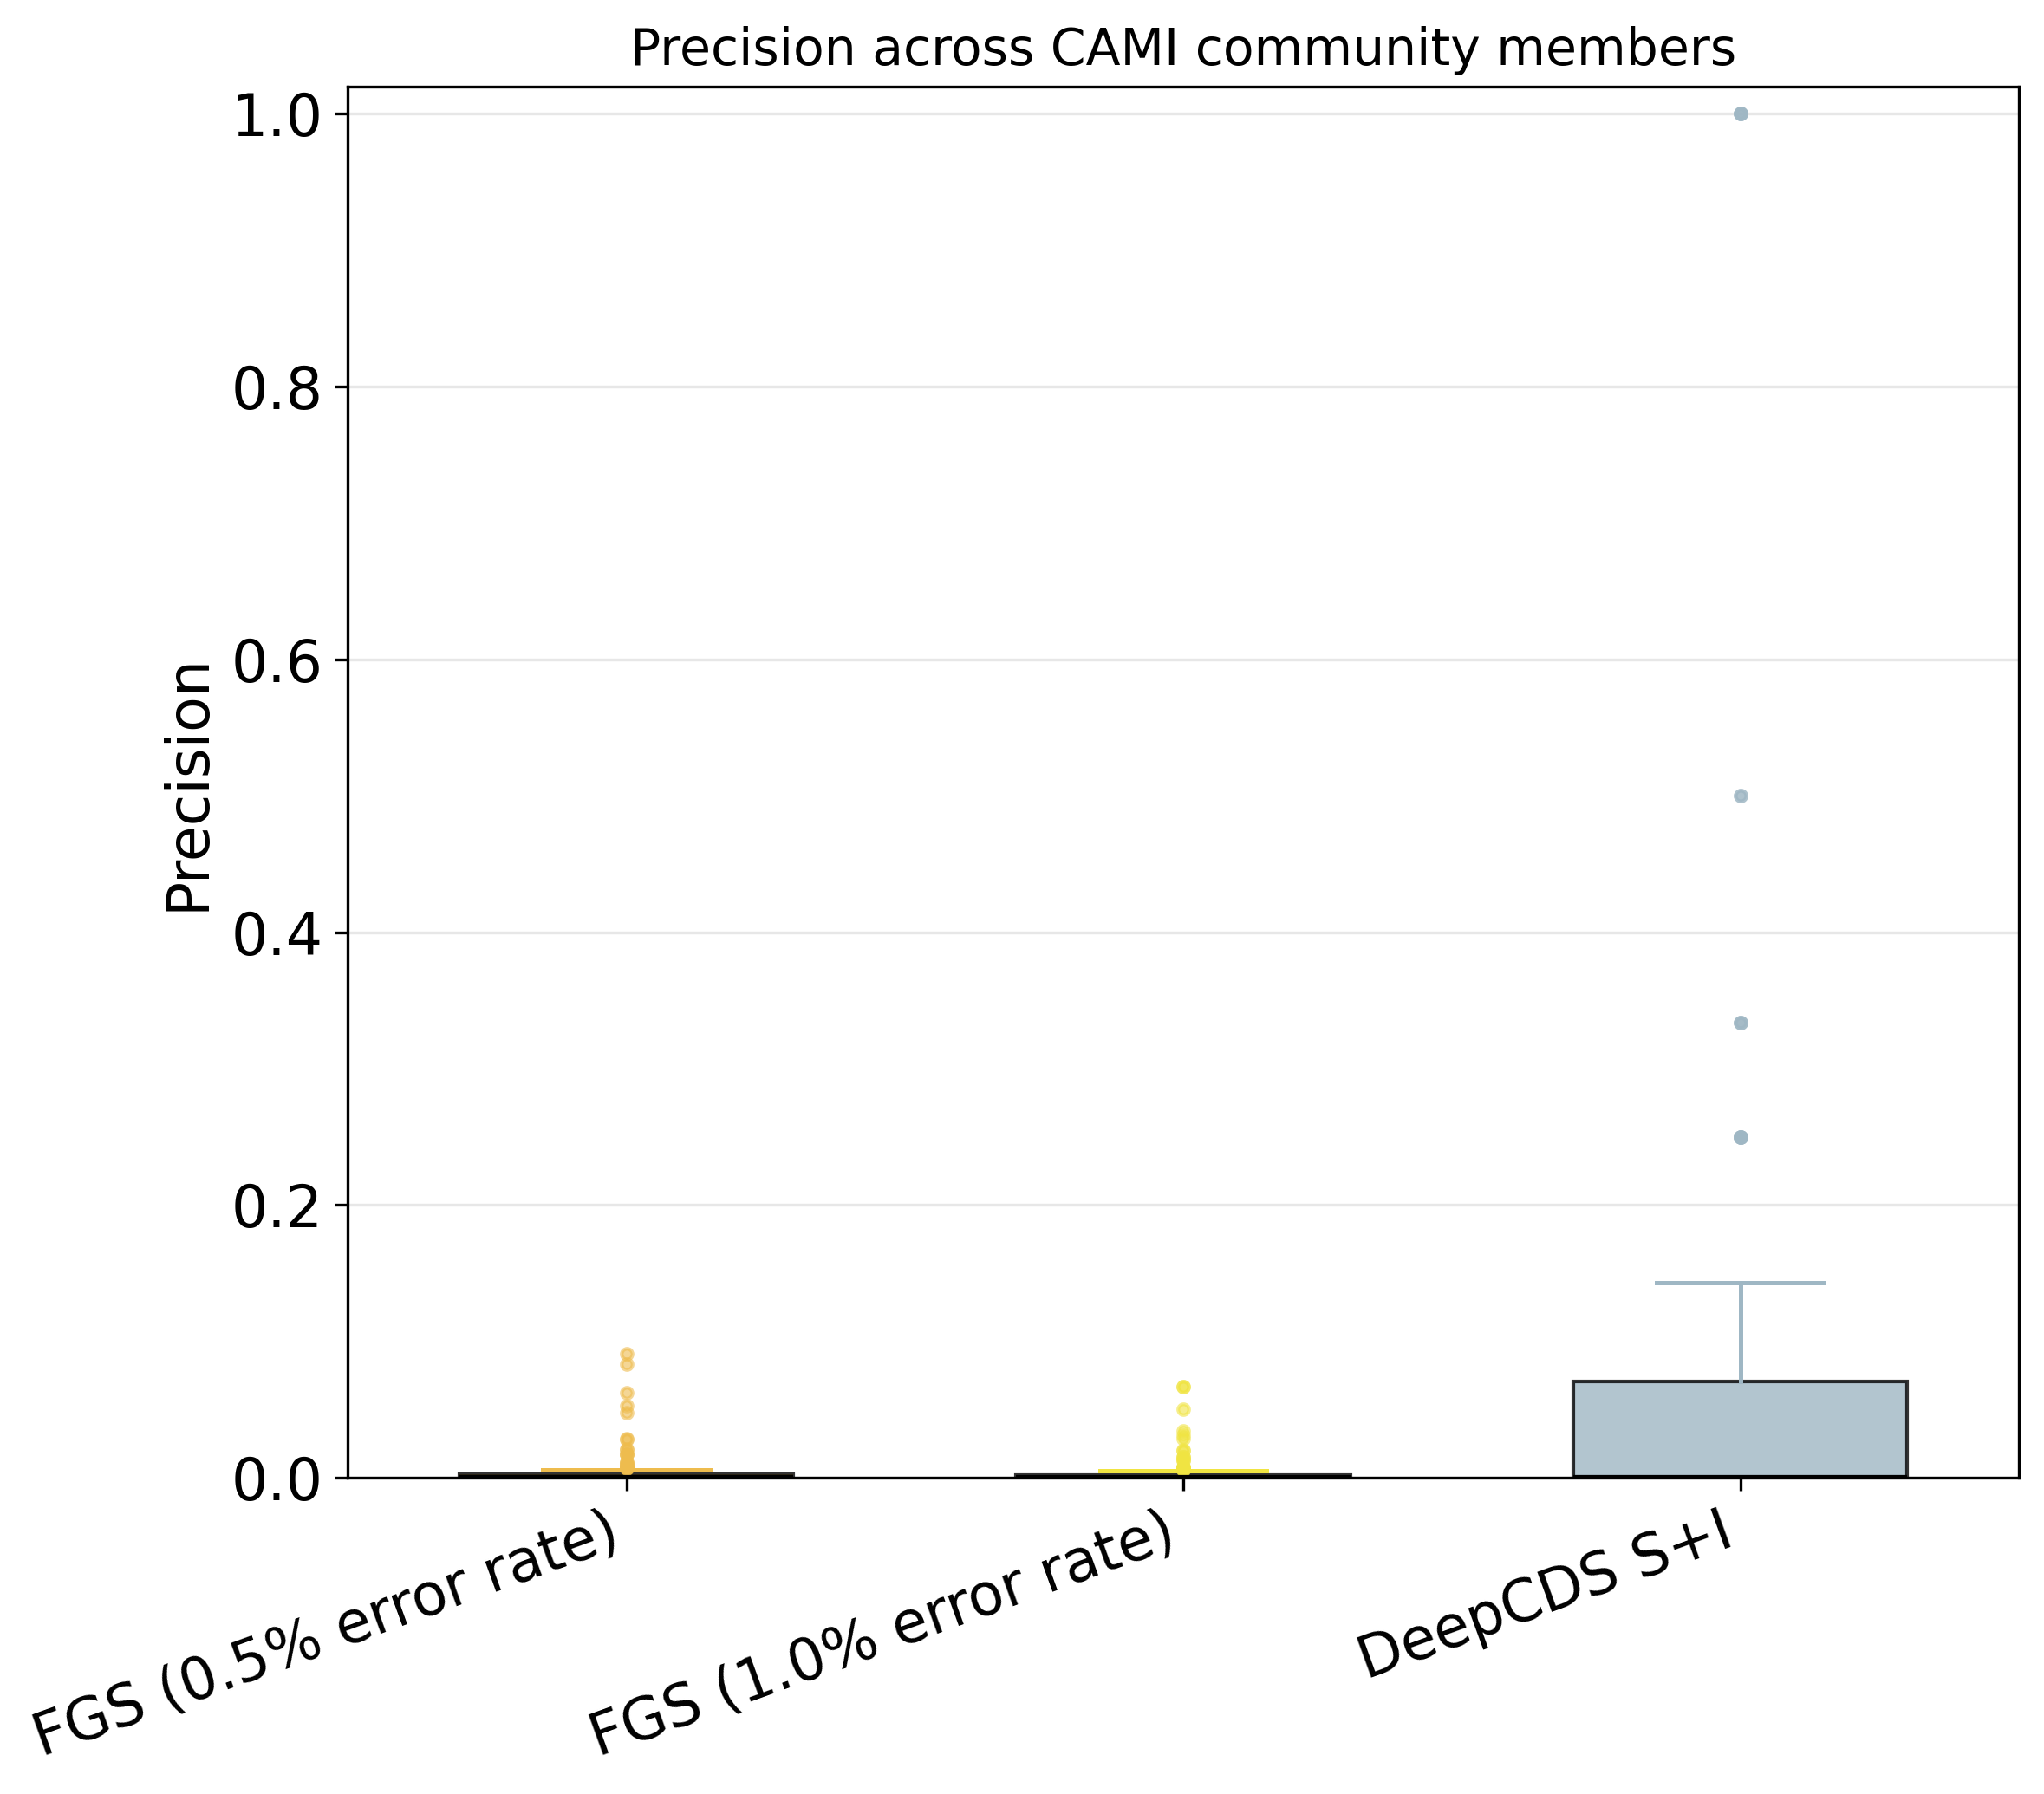

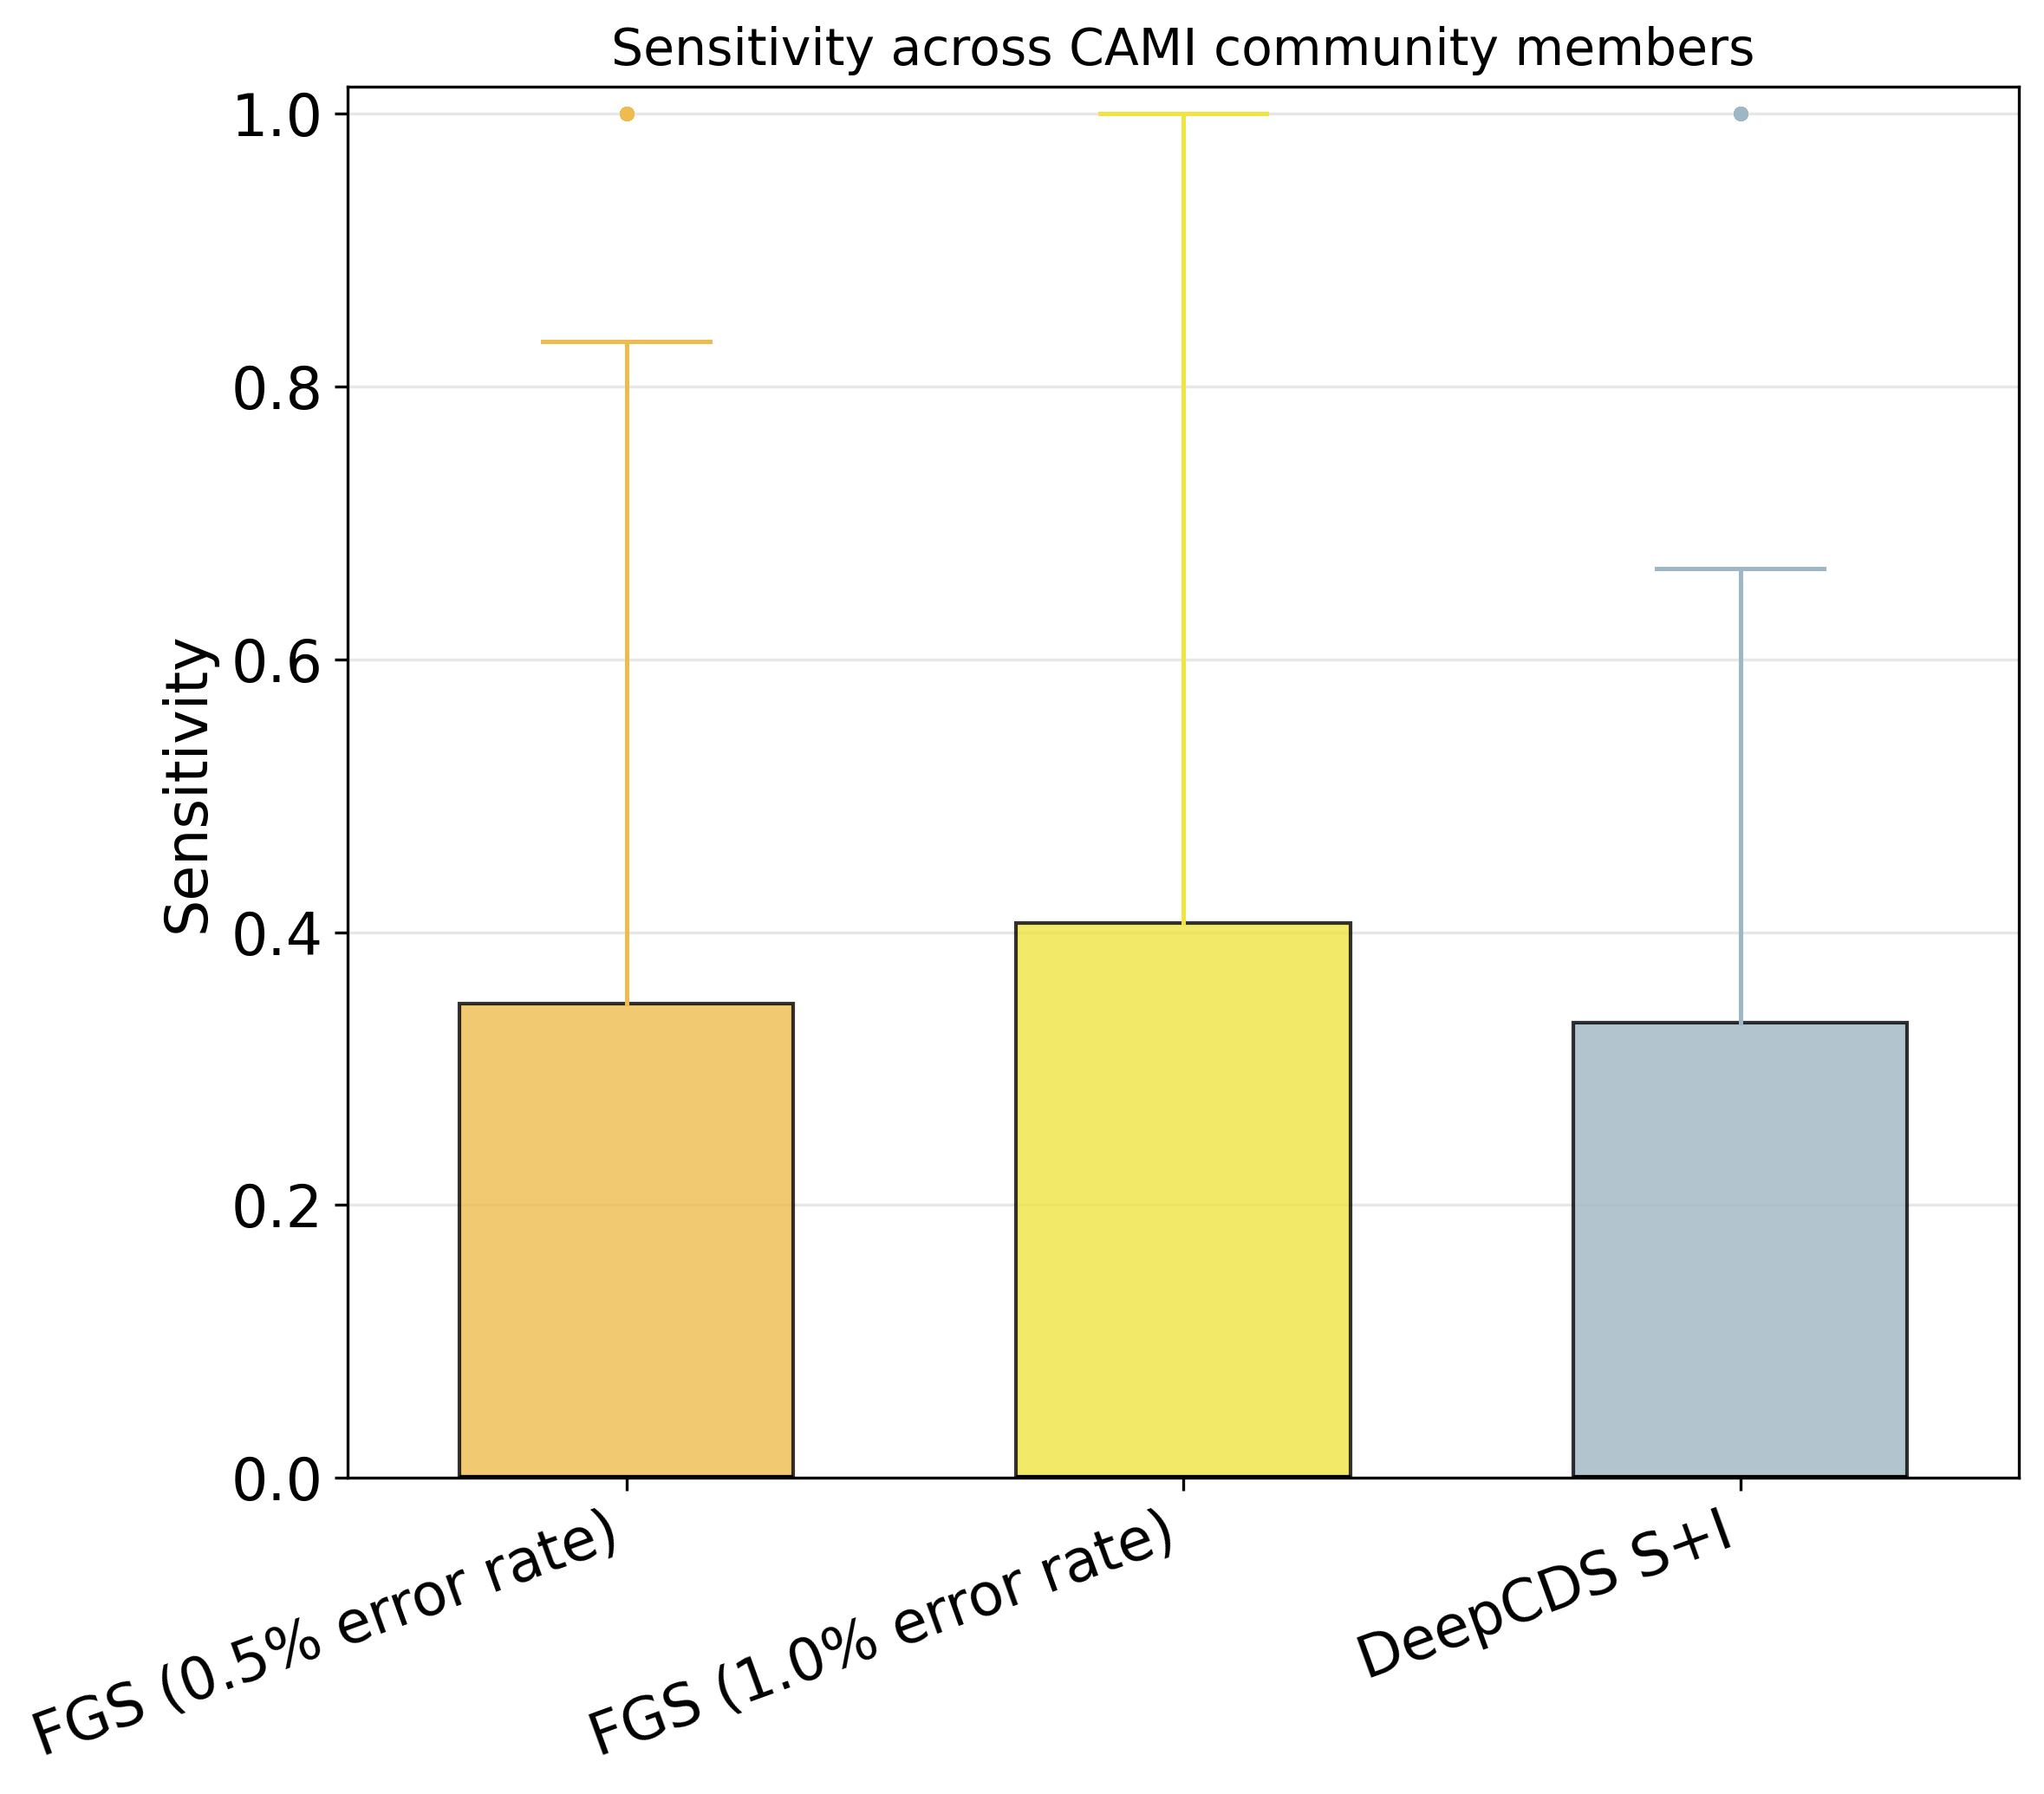

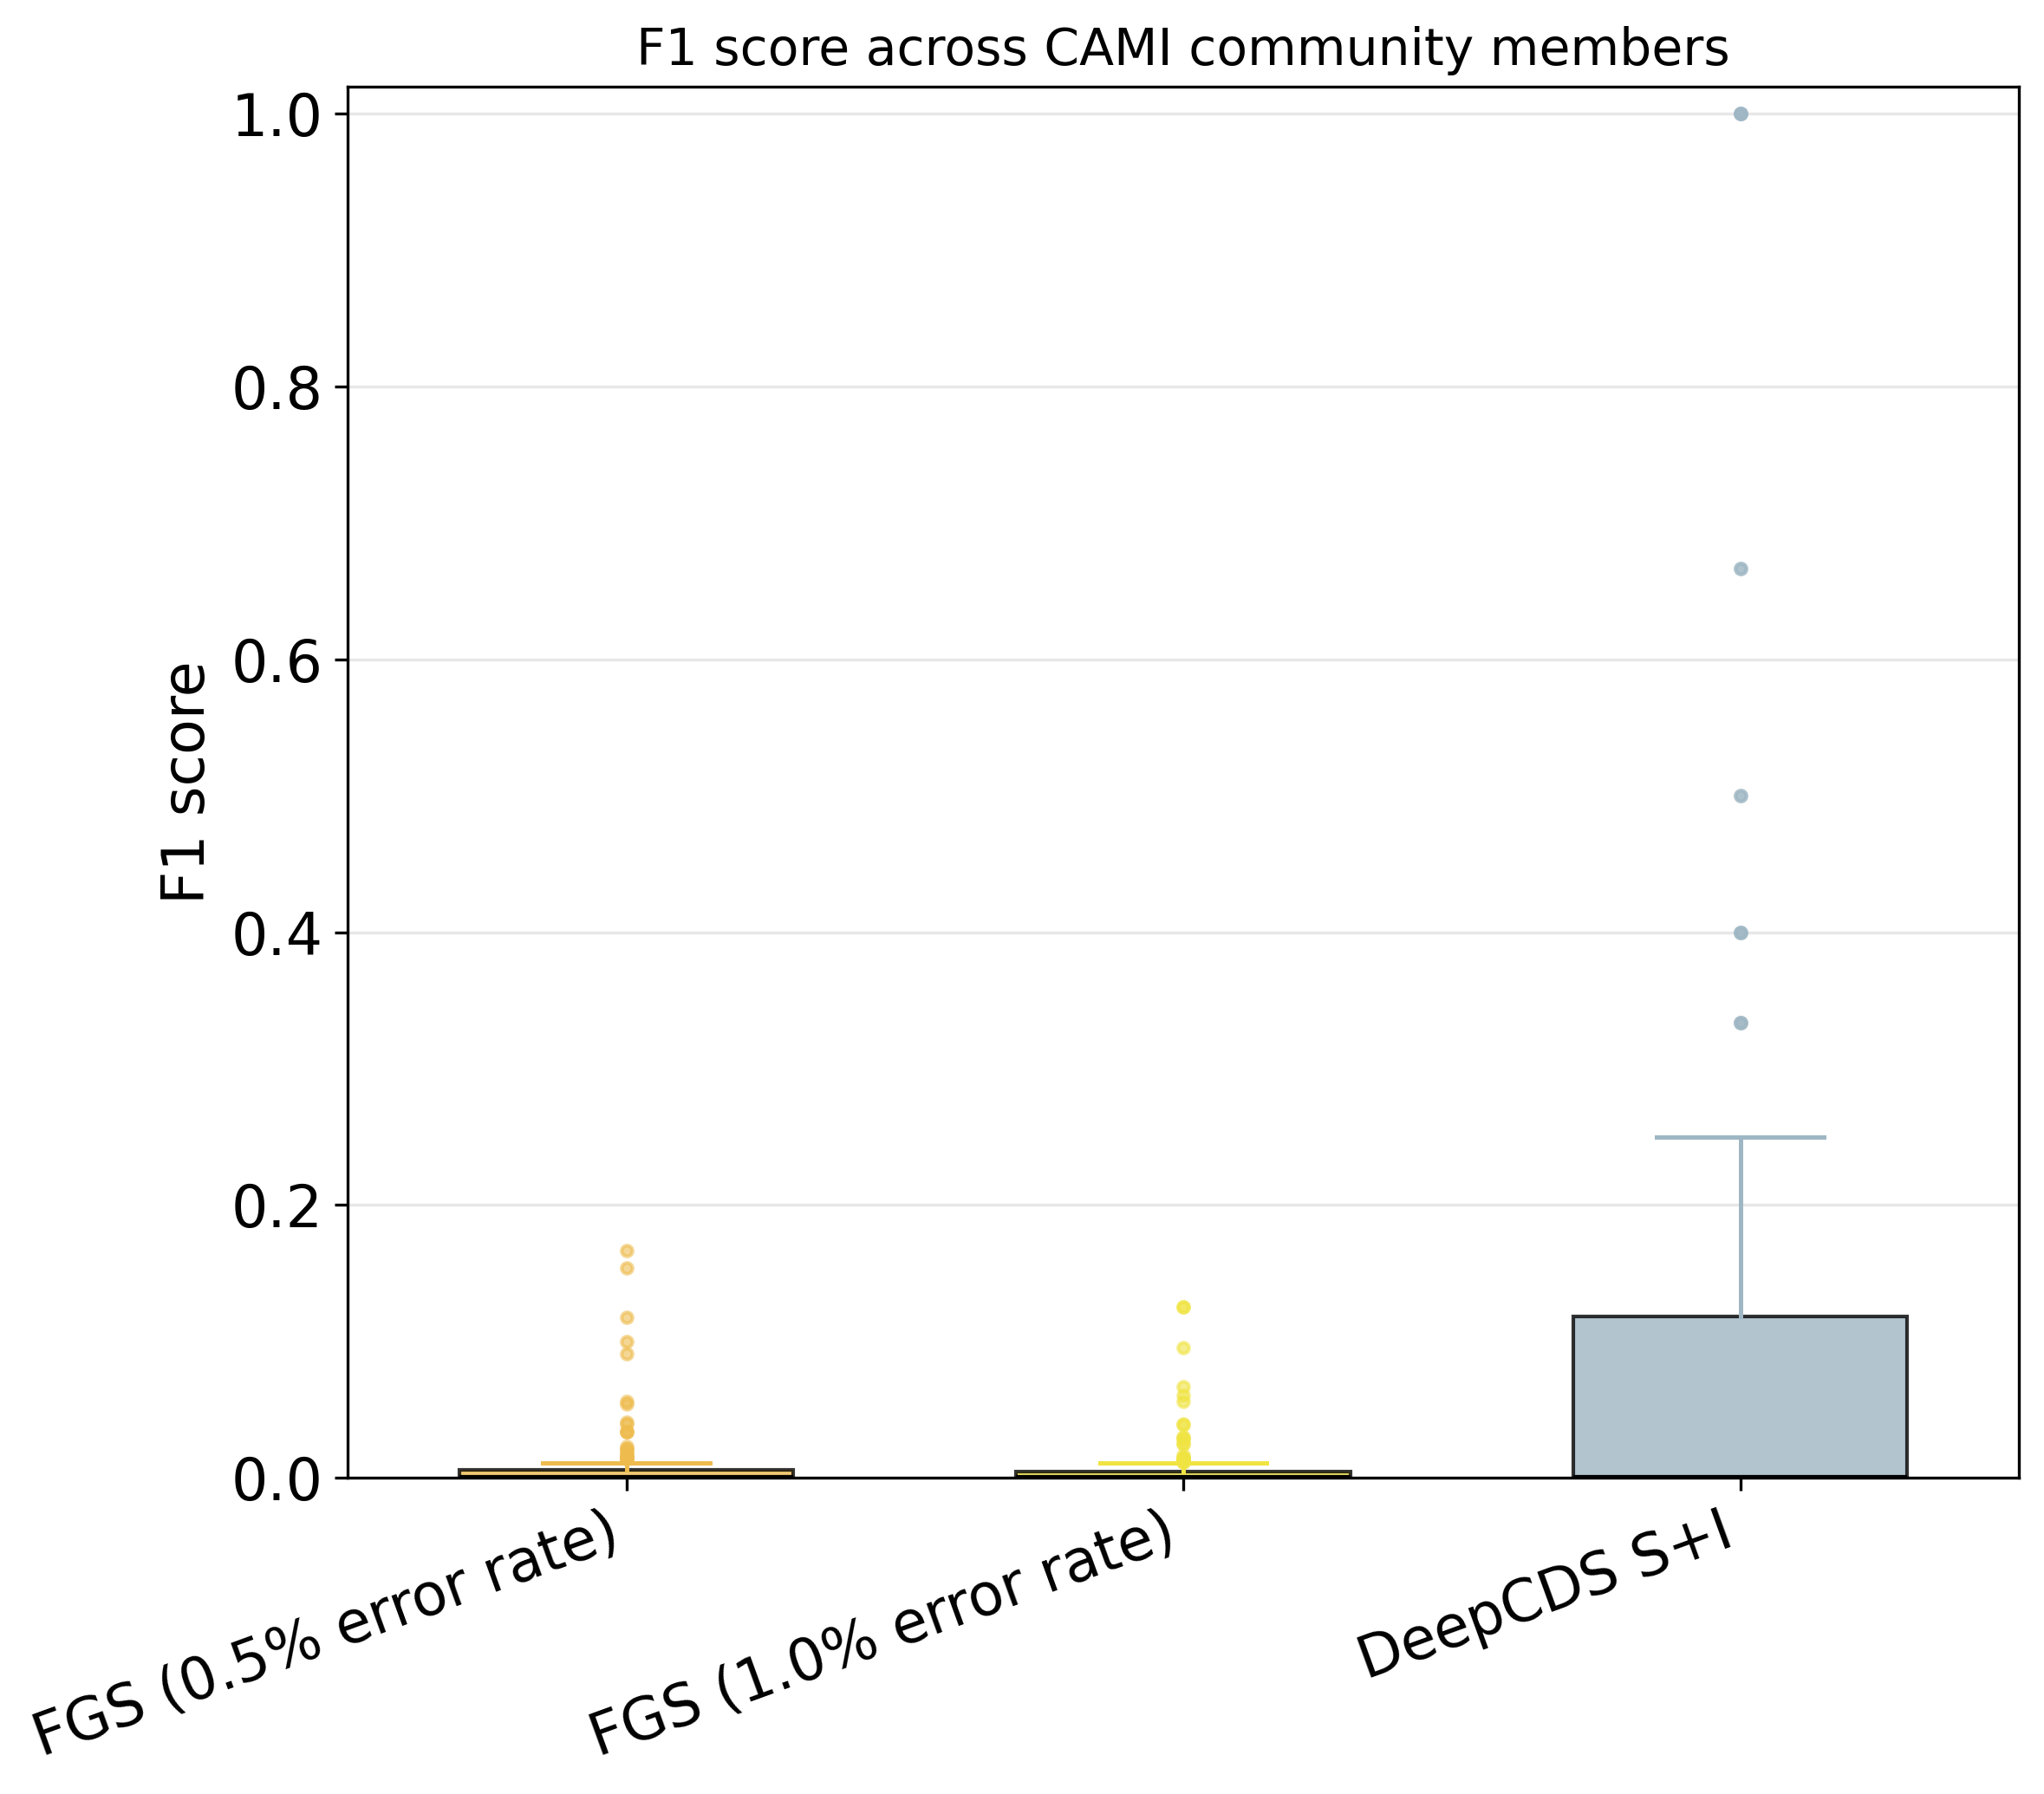

In [9]:
def plot_metric_boxplot(metric_key, ylabel, ylim=(0, 1.05), title=None):
    """One box per model, showing the metric's distribution across CAMI community
    members (genome bins) - the metagenome analog of the genome benchmark's per-genome
    boxplot (there grouped by read length too; here there's a single condition, so one
    box per model). NaNs (e.g. MAE when a bin has no matched indels) are dropped before
    plotting, with a dropped-count annotation under each box.
    """
    active_models = [m for m in MODEL_KEYS if per_genome_bin_results[m][metric_key]]
    if not active_models:
        print("No data available.")
        return

    fig, ax = plt.subplots(figsize=(8, 7))
    x = np.arange(len(active_models))

    for xi, model in zip(x, active_models):
        color = model_colors[model]
        raw = per_genome_bin_results[model][metric_key]
        data = [v for v in raw if not np.isnan(v)]
        n_na = len(raw) - len(data)

        if data:
            bp_dict = ax.boxplot(
                [data], positions=[xi], widths=0.6, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color=color, linewidth=1.2),
                capprops=dict(color=color, linewidth=1.2),
                flierprops=dict(marker='o', markersize=3, markerfacecolor=color,
                                markeredgecolor=color, linestyle='none', alpha=0.6),
                showfliers=True,
            )
            bp_dict['boxes'][0].set_facecolor(color)
            bp_dict['boxes'][0].set_alpha(0.80)

        if n_na > 0:
            ax.annotate(f"*NA={n_na}", xy=(xi, 0), xycoords=('data', 'axes fraction'),
                        xytext=(0, -28), textcoords='offset points',
                        ha='center', va='top', fontsize=8, color=color, annotation_clip=False)

    ax.set_xticks(x)
    ax.set_xticklabels([model_display_names[m] for m in active_models], rotation=20, ha='right')
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_title(title or f"{ylabel} across CAMI community members", fontsize=14)
    ax.grid(True, axis='y', alpha=0.3, linewidth=0.8)

    plt.tight_layout()
    plt.show()


plot_metric_boxplot("MAEs", "MAE", ylim=None)
plot_metric_boxplot("precisions", "Precision", ylim=(0, 1.02))
plot_metric_boxplot("sensitivities", "Sensitivity", ylim=(0, 1.02))
plot_metric_boxplot("f1s", "F1 score", ylim=(0, 1.02))

# Tables: genome-bin-level MAE summary

In [10]:
rows = []
for model in MODEL_KEYS:
    vals = [v for v in per_genome_bin_results[model]["MAEs"] if not np.isnan(v)]
    rows.append({
        "Model": model_display_names[model],
        "Median MAE": round(np.median(vals), 3) if vals else np.nan,
        "Mean +/- std MAE": f"{np.mean(vals):.3f} +/- {np.std(vals):.3f}" if vals else np.nan,
        "N community members": len(vals),
    })

mae_table = pd.DataFrame(rows).set_index("Model")
print("Per-community-member MAE summary")
print(mae_table.to_string())

Per-community-member MAE summary
                       Median MAE   Mean +/- std MAE  N community members
Model                                                                    
FGS (0.5% error rate)       7.321  10.055 +/- 11.499                   89
FGS (1.0% error rate)       7.875  10.246 +/- 11.504                   90
DeepCDS S+I                 5.000    6.090 +/- 6.889                   83
